# singlem benchmark plots
Walltime and CPU time for each singlem stage, version, and run.

In [1]:
def show_all(df, width=200, max_col_width=True):
    '''
    Prints an entire polars dataframe in the console or notebook output.
    Parameters
    ----------
    df : pl.DataFrame
        The dataframe to be printed.
    width : int, optional
        The width of the printed dataframe.
        Defaults to 200.
    max_col_width : bool, optional
        Whether to set the maximum column width.
        i.e. it will print the full contents of the cells.
        Defaults to True.
    '''
    with  pl.Config()  as  cfg:
        cfg.set_tbl_cols(-1)
        cfg.set_tbl_rows(-1)
        cfg.set_tbl_width_chars(width)
        if  max_col_width  or  len(df.columns) ==  1:
            cfg.set_fmt_str_lengths(width)
        print(df)

In [2]:
from pathlib import Path
import json
import os
import polars as pl
import glob

benchmark_files = []
for path in glob.glob("snakedata/benchmarks/singlem*/*/*.txt", recursive=True):
    benchmark_files.append(path)

records = []
for path_str in benchmark_files:
    path = Path(path_str)
    parts = path.parts
    if len(parts) < 5:
        continue
    stage = parts[2]
    version = parts[3]
    run = parts[4].rsplit(".", 1)[0]
    df = pl.read_csv(path, separator="\t")
    if df.height == 0:
        continue
    row = df.row(0, named=True)
    if row["cpu_time"] == "NA":
        continue
    records.append({
        "stage": stage,
        "version": version,
        "run": run,
        "wall_seconds": float(row.get("s", float("nan"))),
        "cpu_seconds": float(row.get("cpu_time", float("nan"))),
        # "cpu": row.get("cpu_time", ""),
    })
print("Parsed {} benchmark files.".format(len(records)))

df = pl.DataFrame(records)
df
df_long = (
    df.melt(id_vars=["stage", "version", "run"], value_vars=["wall_seconds", "cpu_seconds"], variable_name="metric", value_name="seconds")
    if df.height > 0
    else pl.DataFrame()
)
df_long = df_long.with_columns((pl.col("stage") + " / " + pl.col("version")).alias("stage_version"))
df_long

# Rename sample labels to be more informative
# "SRR9224014" => 'human
# "methanobacteria_genomes" => 'genome'
# "SRR1926147" => 'soil'
# "DRR083195" => 'marine'
# "ERR11563597" => 'nanopore'

df_long = df_long.with_columns(
    pl.col("run").str.replace_all("SRR9224014", "human")
    .str.replace_all("methanobacteria_genomes", "genome")
    .str.replace_all("SRR1926147", "soil")
    .str.replace_all("DRR083195", "marine")
    .str.replace_all("ERR11563597", "nanopore")
)

Parsed 35 benchmark files.


/tmp/ipykernel_28630/3992982715.py:39: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  df.melt(id_vars=["stage", "version", "run"], value_vars=["wall_seconds", "cpu_seconds"], variable_name="metric", value_name="seconds")


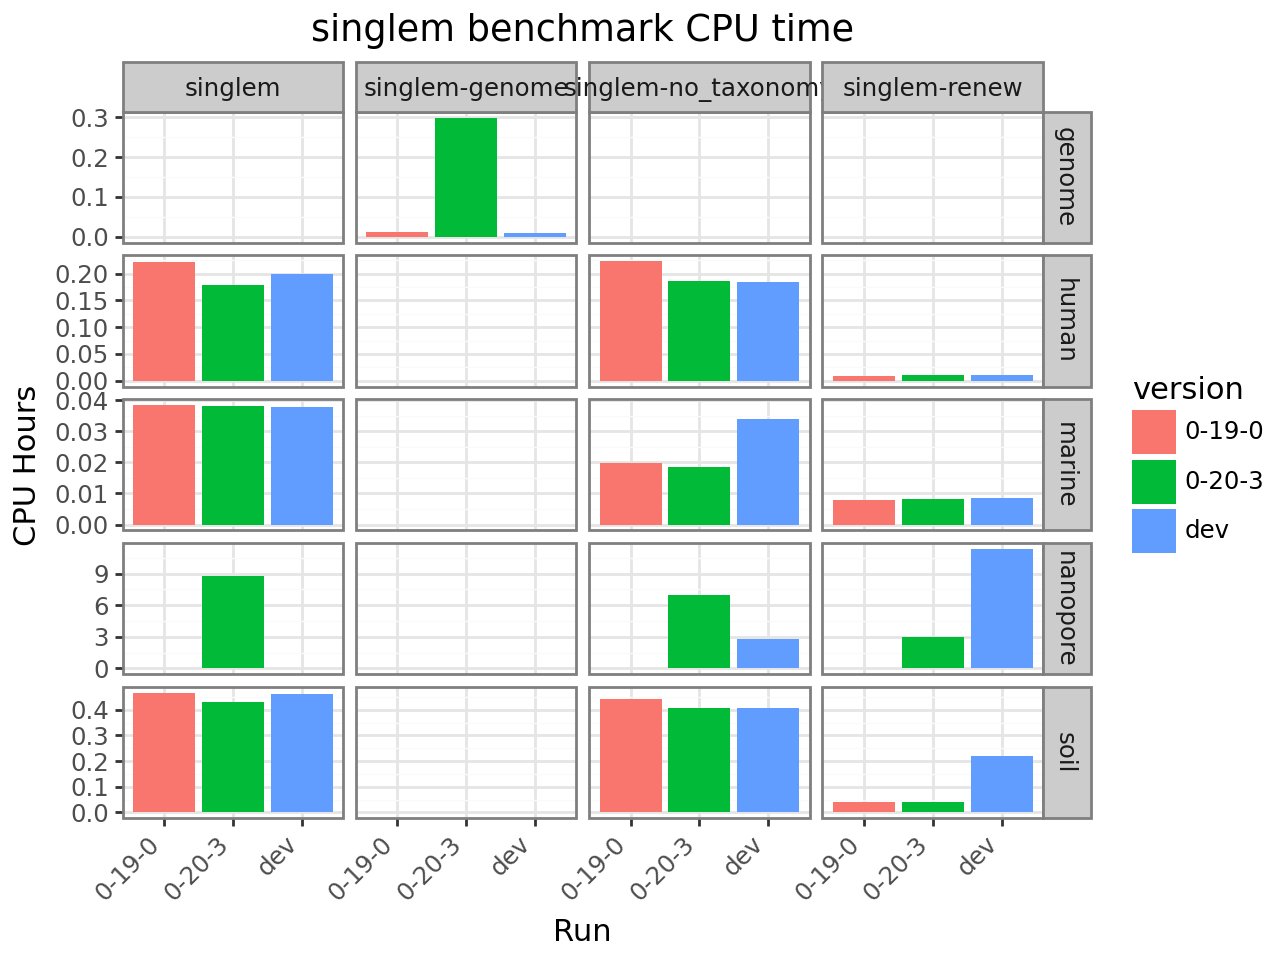

In [3]:
from plotnine import ggplot, aes, geom_col, facet_grid, theme_bw, labs, position_dodge, theme, element_text

df_long = df_long.with_columns(
    (pl.col('seconds') / 3600).alias('hours'),
)


if df_long.height == 0:
    raise ValueError("No benchmark data available for plotting.")
# Just look at CPU time atm
(ggplot(df_long.filter(pl.col("metric") == "cpu_seconds"), aes(x="version", y="hours", fill="version"))
+ geom_col(position=position_dodge())
+ facet_grid("run~stage", scales="free_y")
+ theme_bw()
+ labs(x="Run", y="CPU Hours", title="singlem benchmark CPU time")
+ theme(axis_text_x=element_text(rotation=45, hjust=1)))

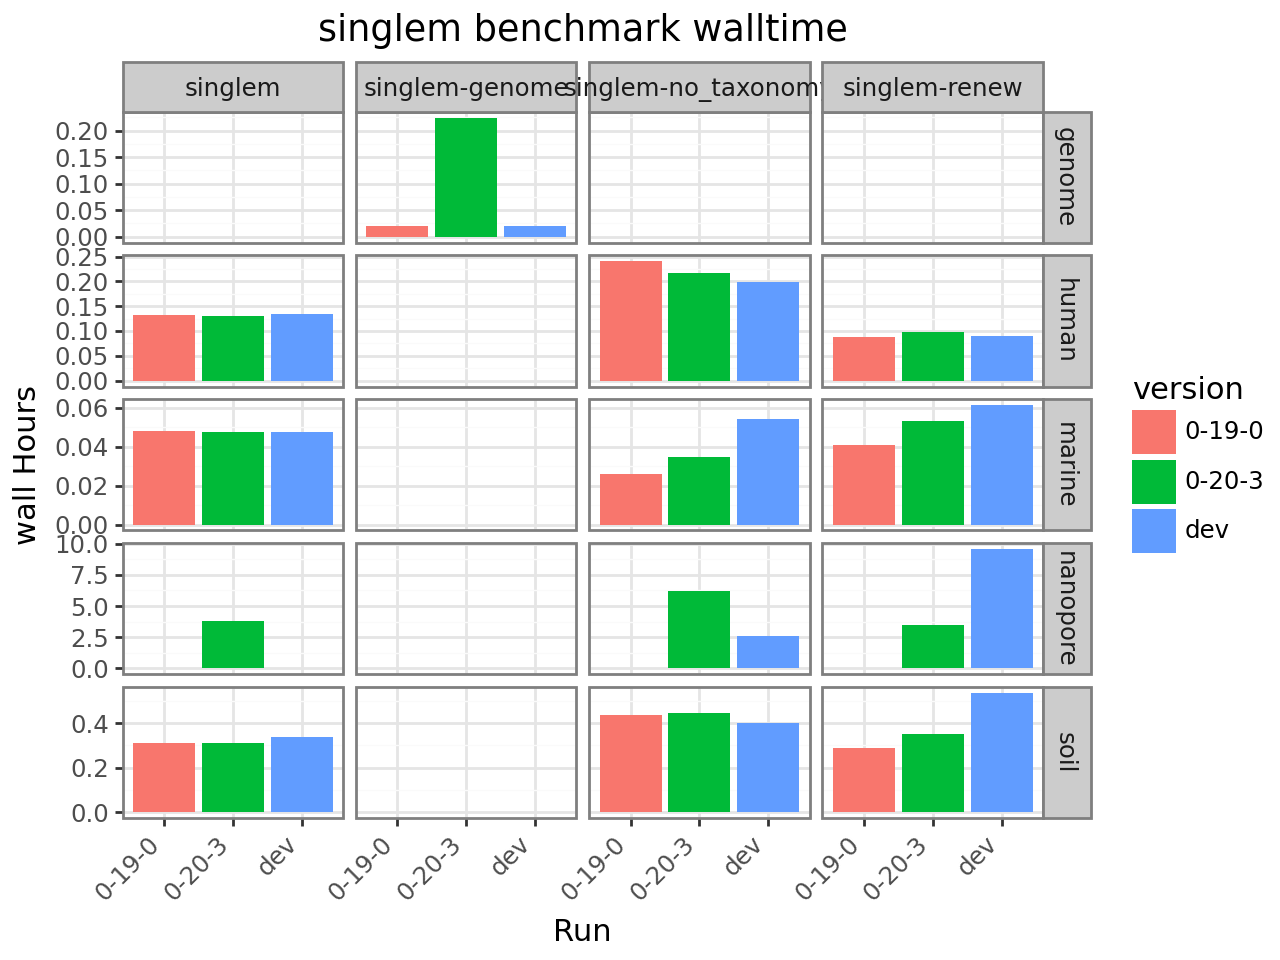

In [4]:
if df_long.height == 0:
    raise ValueError("No benchmark data available for plotting.")
# Just look at CPU time atm
(ggplot(df_long.filter(pl.col("metric") == "wall_seconds"), aes(x="version", y="hours", fill="version"))
+ geom_col(position=position_dodge())
+ facet_grid("run~stage", scales="free_y")
+ theme_bw()
+ labs(x="Run", y="wall Hours", title="singlem benchmark walltime")
+ theme(axis_text_x=element_text(rotation=45, hjust=1)))

## OTU comparison

In [5]:
# How many OTUs are being reported, and what is the total coverage?
df_otus = []
# glob snakedata/singlem-no_taxonomy/dev/*.otu_table.tsv
import glob
for path in glob.glob("snakedata/singlem-*/*/*.otu_table.tsv", recursive=True):
    print(path)
    parts = Path(path).parts
    stage = parts[1]
    version = parts[2]
    run = parts[3].rsplit(".", 1)[0]
    df_otu = pl.read_csv(path, separator="\t")
    if df_otu.height == 0:
        continue
    total_coverage = df_otu["coverage"].sum()
    num_otus = df_otu.height
    df_otus.append({
        "stage": stage,
        "version": version,
        "run": run,
        "num_otus": num_otus,
        "total_coverage": total_coverage,
    })
df_otus = pl.DataFrame(df_otus)
df_otus


snakedata/singlem-renew/dev/SRR1926147.otu_table.tsv
snakedata/singlem-renew/dev/SRR9224014.otu_table.tsv
snakedata/singlem-renew/dev/DRR083195.otu_table.tsv
snakedata/singlem-renew/dev/ERR11563597.otu_table.tsv
snakedata/singlem-renew/0-19-0/SRR1926147.otu_table.tsv
snakedata/singlem-renew/0-19-0/SRR9224014.otu_table.tsv
snakedata/singlem-renew/0-19-0/DRR083195.otu_table.tsv
snakedata/singlem-renew/0-20-3/SRR1926147.otu_table.tsv
snakedata/singlem-renew/0-20-3/SRR9224014.otu_table.tsv
snakedata/singlem-renew/0-20-3/DRR083195.otu_table.tsv
snakedata/singlem-renew/0-20-3/ERR11563597.otu_table.tsv
snakedata/singlem-genome/dev/methanobacteria_genomes.otu_table.tsv
snakedata/singlem-genome/0-19-0/methanobacteria_genomes.otu_table.tsv
snakedata/singlem-genome/0-20-3/methanobacteria_genomes.otu_table.tsv
snakedata/singlem-no_taxonomy/dev/SRR1926147.otu_table.tsv
snakedata/singlem-no_taxonomy/dev/SRR9224014.otu_table.tsv
snakedata/singlem-no_taxonomy/dev/DRR083195.otu_table.tsv
snakedata/sing

stage,version,run,num_otus,total_coverage
str,str,str,i64,f64
"""singlem-renew""","""dev""","""SRR1926147.otu_table""",11486,23053.93
"""singlem-renew""","""dev""","""SRR9224014.otu_table""",3772,34529.52
"""singlem-renew""","""dev""","""DRR083195.otu_table""",348,856.14
"""singlem-renew""","""dev""","""ERR11563597.otu_table""",160193,295323.92
"""singlem-renew""","""0-19-0""","""SRR1926147.otu_table""",11462,23012.16
…,…,…,…,…
"""singlem-no_taxonomy""","""0-19-0""","""DRR083195.otu_table""",343,844.44
"""singlem-no_taxonomy""","""0-20-3""","""SRR1926147.otu_table""",11488,23056.92
"""singlem-no_taxonomy""","""0-20-3""","""SRR9224014.otu_table""",3772,34529.51


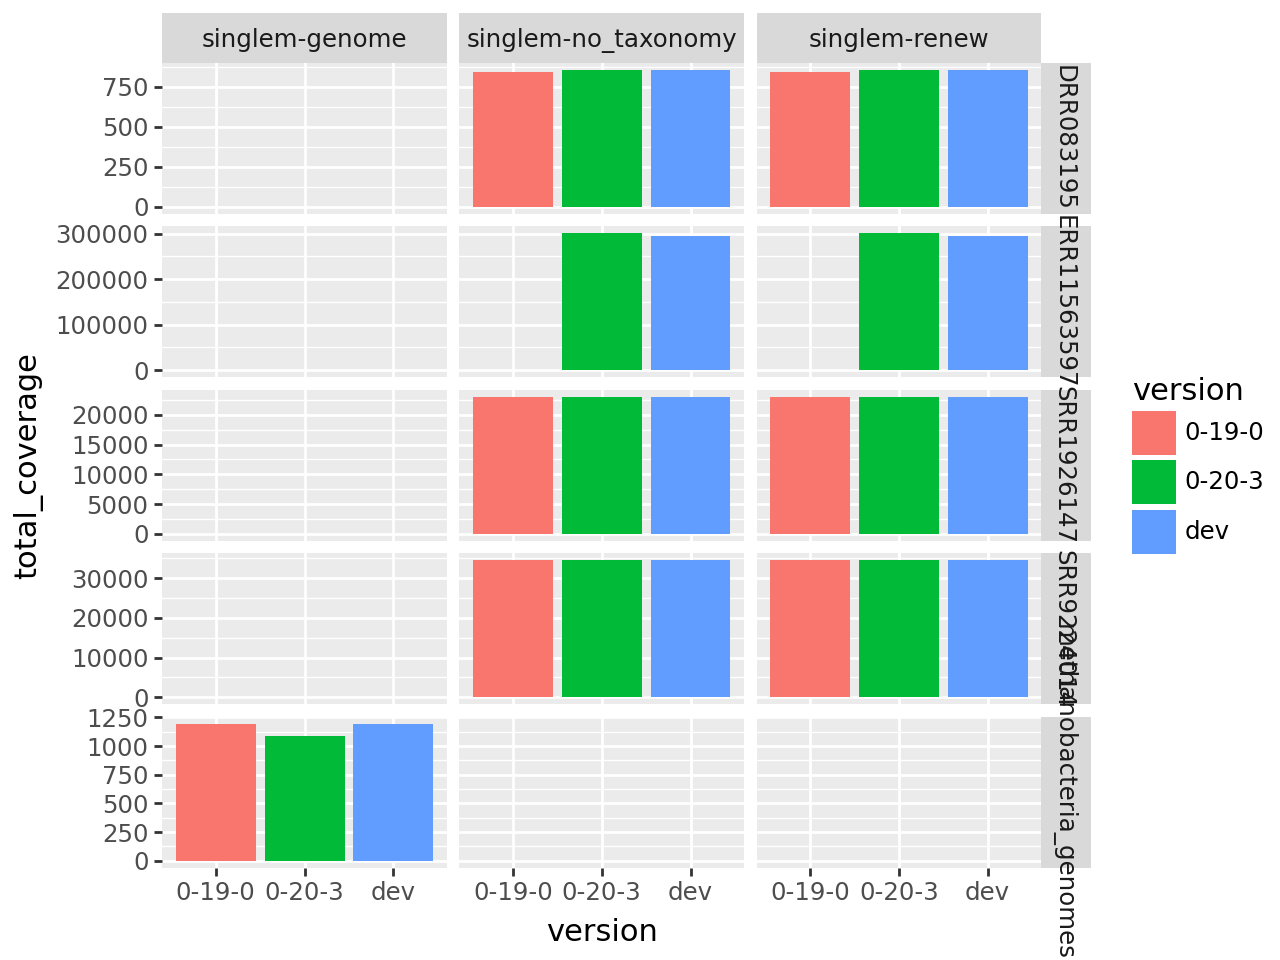

In [6]:
# Plot
# df_otus_long = df_otus.melt(id_vars=["stage", "version", "run"], value_vars=["num_otus", "total_coverage"], variable_name="metric", value_name="value")
# Remove .otu_table* from run column
df_otus = df_otus.with_columns(
    pl.col("run").str.replace(r"\.otu_table.*$", "", literal=False)
)
ggplot(df_otus, aes(x="version", y="total_coverage", fill="version")) \
+ geom_col(position=position_dodge()) \
+ facet_grid("run~stage", scales="free_y")
# + theme_bw() \
# + labs(x="Run", y="Value", title="singlem benchmark OTU counts and coverage") #\
# + theme(axis_text_x=element_text(rotation=45, hjust=1)) 

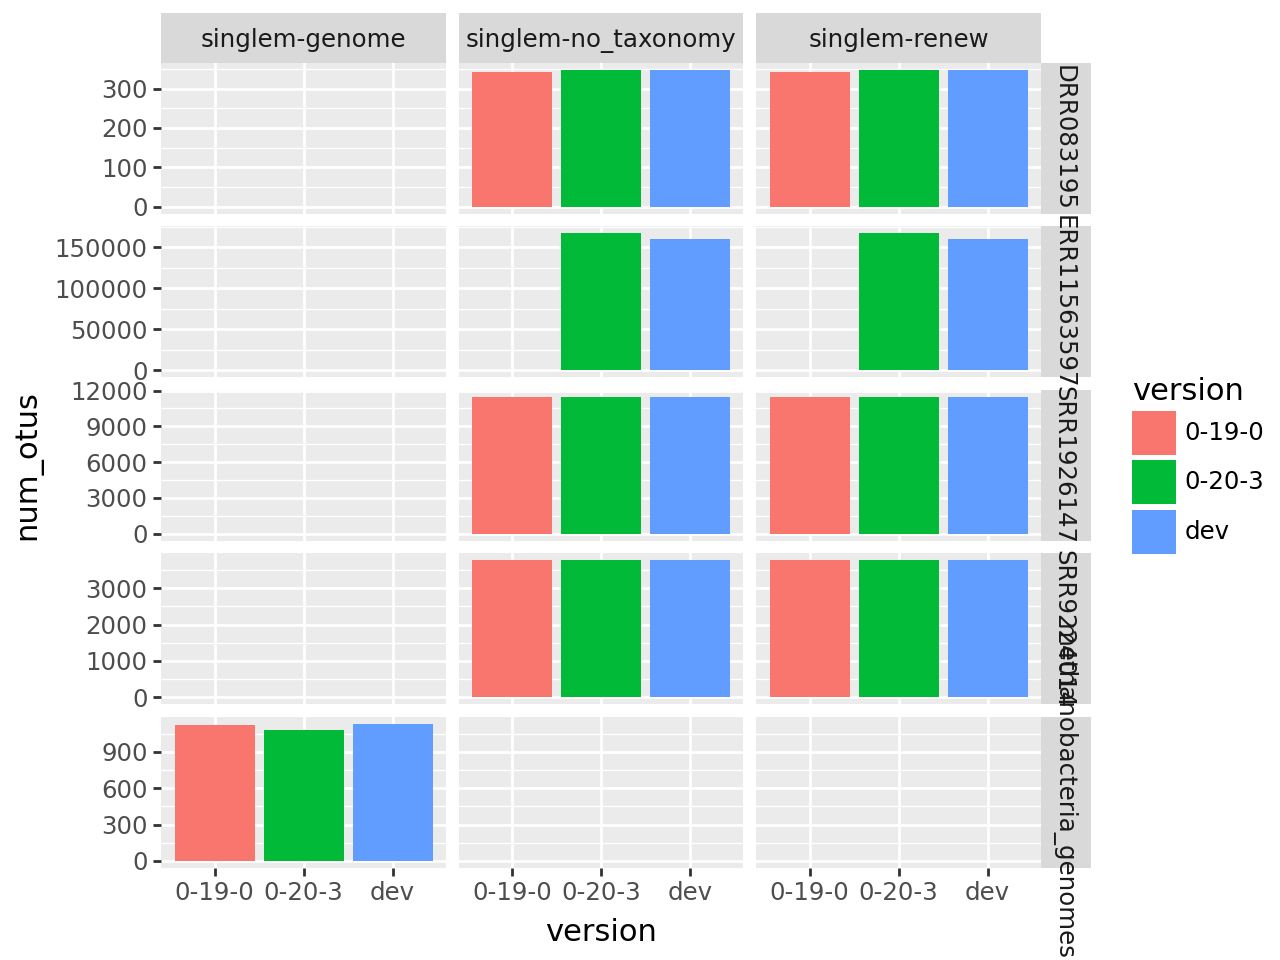

In [7]:
ggplot(df_otus, aes(x="version", y="num_otus", fill="version")) \
+ geom_col(position=position_dodge()) \
+ facet_grid("run~stage", scales="free_y")

In [8]:
df_otus.pivot( values=["total_coverage"], index=["stage", "run"], columns="version")

/tmp/ipykernel_28630/1544403496.py:1: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.


stage,run,dev,0-19-0,0-20-3
str,str,f64,f64,f64
"""singlem-renew""","""SRR1926147""",23053.93,23012.16,23056.92
"""singlem-renew""","""SRR9224014""",34529.52,34515.34,34529.52
"""singlem-renew""","""DRR083195""",856.14,844.44,856.14
"""singlem-renew""","""ERR11563597""",295323.92,null,301055.12
"""singlem-genome""","""methanobacteria_genomes""",1195.0,1191.0,1085.48
"""singlem-no_taxonomy""","""SRR1926147""",23053.93,23012.16,23056.92
"""singlem-no_taxonomy""","""SRR9224014""",34529.51,34515.34,34529.51
"""singlem-no_taxonomy""","""DRR083195""",856.14,844.44,856.14
"""singlem-no_taxonomy""","""ERR11563597""",295323.91,null,301055.09


In [9]:
# So currently dev has slightly less OTUs than 0.20 on the nanopore dataset. Why? Get an example sequence
otus_dev = pl.read_csv("snakedata/singlem-no_taxonomy/dev/ERR11563597.otu_table.tsv", separator="\t")
otus_020 = pl.read_csv("snakedata/singlem-no_taxonomy/0-20-3/ERR11563597.otu_table.tsv", separator="\t")
# Find an OTU in 0.20.3 that is not in dev
set_020 = set(otus_020["sequence"])
set_dev = set(otus_dev["sequence"])
diff = set_020 - set_dev

In [10]:
print(len(diff))
# Get a randomly chosen example sequence
import random

for i in range(5):
    example_seq = random.choice(list(diff))
    # example_seq = 'CGTGTTCGAGCGCGCCACGGTAGGACGAGGACGAGGAGGCGCTCGGACCAAACCAGGCGA'
    print(example_seq)
    # show_all(otus_020.filter(pl.col("sequence") == example_seq))

    # Are there any other OTUs from that read?
    read_name = otus_020.filter(pl.col("sequence") == example_seq)["read_names"].str.split(' ').map_elements(lambda x: x[0])[0]
    print(read_name, otus_dev.filter(pl.col("read_names").str.contains(read_name)).height)

# 16269
# GAGCACATCGCGGTCAGCGAGGCGCGCAAGCTGGGCATCCCGGTCGTGGGCATCCTCGAC
# ERR11563597.4084185 1
# AAACCGTGCAGCAACATAACAAGCACGACCGAGAAGATCTACCGGCAGAAGGGCACGGGC
# ERR11563597.5891019 2
# GCGGCAACGACCTTGCAGCCTGCCTCGATGTCATCGGCGAAGCCGCCACTCGGGCGCGAA
# ERR11563597.7990322 2
# GTCATCAAGCTTTTAAAAGAAAGTGGTCAATTAGAAAAATCACAAAAAATCGCGCGGGAT
# ERR11563597.2503605 1
# AAGCGAATTTCCAATTGAACTGGCTTGGTCCGTTCGTTATCAAAAAGATATGCCCTTTTG
# ERR11563597.7666936 1

# So not all of these are multi-OTU reads, some are single OTU reads that are missing in dev. Why?
# (conda)aquarius01:20251216:~/git/singlem/extras/performance_benchmarking$ seqkit grep -p ERR11563597.4084185 snakedata/reads/ERR11563597.fastq.gz >t/ERR11563597.4084185.fq

16269
CTGCGCTGTTTGCCCGGAGTCGGACCTGAGTCGGCGCAACGCATGGCTTTCTACCTGCTC
ERR11563597.7345791 0
GTACCTTTACCATCTGAGAGTGGCCTGACGACAGATATCTATGCTCAGCGGGTTCAATCC
ERR11563597.7272556 1
GGCGTCTTCGTCGAAATCGAGCCGGGC------ATCGACGGCCTCGTGCACATTTCGGAT
ERR11563597.5770164 1
GCTTTTAGCTGATATAAACAAAAAAAGATCTGAAGTGTTACAAAATCAAGCAAATGTTCT
ERR11563597.4859233 1
GGCGCTTTCATCGAGATCGAAGACGGA------ATTGACGGCCTGGTCCACGTCAGCAAT
ERR11563597.2389054 1
